In [30]:
import torch
import numpy as np
import pandas as pd

emb = torch.load(
    "embeddings/fold_4_embeddings.pt"
)

tissue_emb = emb["epoch99"]["tissue"]
plasma_emb = emb["epoch99"]["plasma"]


patients = sorted(
    set(tissue_emb.keys()) &
    set(plasma_emb.keys())
)

print(len(patients))

10


In [59]:
print(tissue_emb.keys())

dict_keys(['Sample 20', 'Sample 24', 'Sample 30', 'Sample 36', 'Sample 39', 'Sample 45', 'Sample 55', 'Sample 72', 'Sample 77', 'Sample 90'])


In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
def plot(pca_df, fold, proj = False, epoch=0):
    patients = sorted(
    set(pca_df["patient"])
    )

    # Create a color mapping for patients
    colors = cm.get_cmap("tab20", len(patients))
    patient_colors = {
        patient: colors(i)
        for i, patient in enumerate(patients)
    }

    plt.figure(figsize=(7,6))



    for patient in patients:

        color = patient_colors[patient]

        tissue = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Tissue")
        ].iloc[0]

        plasma = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Plasma")
        ].iloc[0]

        t = tissue[["PC1", "PC2"]].values
        p = plasma[["PC1", "PC2"]].values


        plt.scatter(
            t[0],
            t[1],
            marker="o",
            color = color,
            label="Tissue" if patient == patients[0] else ""
        )

        plt.scatter(
            p[0],
            p[1],
            marker="^",
            color=color,
            label="Plasma" if patient == patients[0] else ""

        )


        plt.plot(
            [t[0],p[0]],
            [t[1],p[1]],
            color=color,
            alpha=0.3
        )

    if proj == True:
        emb_type = 'projected embedding'
    else:
        emb_type = 'encoded embedding'
    plt.title(
        f"Patient-wise tissue-plasma {emb_type} alignment after {epoch} epochs"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()


    # plt.savefig(f'embeddings/plots/embeddings_fold_{fold}_{epoch}_{emb_type}.png',
    #     bbox_inches="tight")
    plt.show()




In [32]:
def compute_PCA(plasma_emb, tissue_emb):
    X = []
    labels = []
    modalities = []
    patients = sorted(
        set(tissue_emb.keys()) &
        set(plasma_emb.keys())
    )

    for patient in patients:

        X.append(
            tissue_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Tissue")


        X.append(
            plasma_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Plasma")


    X = np.stack(X)
    pca = PCA(
        n_components=2
    )

    X_pca = pca.fit_transform(X)
    pca_df = pd.DataFrame({
    "patient": labels,
    "modality": modalities,
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1]
})
    return pca, pca_df


In [33]:
def paired_distances_per_pc(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        distances = []

        for patient in pca_df["patient"].unique():

            tissue = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Tissue")
            ][pc].values[0]

            plasma = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Plasma")
            ][pc].values[0]

            distances.append(abs(tissue - plasma))

        results.append({
            "PC": pc,
            "mean_distance": np.mean(distances),
            "std_distance": np.std(distances)
        })

    return pd.DataFrame(results)

In [34]:
def modality_separation(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        tissue_values = pca_df[
            pca_df["modality"] == "Tissue"
        ][pc]

        plasma_values = pca_df[
            pca_df["modality"] == "Plasma"
        ][pc]

        separation = abs(
            tissue_values.mean() -
            plasma_values.mean()
        )

        results.append({
            "PC": pc,
            "modality_separation": separation,
            "tissue_mean": tissue_values.mean(),
            "plasma_mean": plasma_values.mean()
        })

    return pd.DataFrame(results)

In [216]:
def visualize_embeddings(proj=False):
    all_pc_distances = []
    all_pc_separations = []
    all_variance =[]
    pc_all_folds ={}

    for fold in range(5):
        if proj:
            emb = torch.load(
            f"embeddings/fold_{fold}_embeddings_proj.pt"
            )
        else:
            emb = torch.load(
            f"embeddings/fold_{fold}_embeddings.pt"
            )

        tissue_emb_0 = emb["epoch0"]["tissue"]
        plasma_emb_0 = emb["epoch0"]["plasma"]

        tissue_emb_99 = emb["epoch99"]["tissue"]
        plasma_emb_99 = emb["epoch99"]["plasma"]
        
        
        patients = sorted(
            set(tissue_emb_99.keys()) &
            set(plasma_emb_99.keys())
        )

        pca_0, pca_0_df = compute_PCA(plasma_emb_0, tissue_emb_0)
        pca_99, pca_99_df = compute_PCA(plasma_emb_99, tissue_emb_99)
        
        pca_0_df['fold']= fold
        pc_all_folds[fold] = pca_0_df.copy()
        
        from sklearn.metrics import roc_auc_score

        for pc in ["PC1", "PC2"]:

            values = pca_0_df[pc].values

            labels = (
                pca_0_df["modality"] == "Plasma"
            ).astype(int)

            auc = roc_auc_score(labels, values)

            print(pc, auc)


        distance = paired_distances_per_pc(pca_0_df)
        distance["fold"] = fold
        print(f'Distances Fold {fold}')
        print(distance)

        all_pc_distances.append(distance)

        separation = modality_separation(pca_0_df)
        separation["fold"] = fold

        print(f"Fold {fold} separation")
        print(separation)
        all_pc_separations.append(separation)

        explained_variance = pd.DataFrame({
        "PC": [f"PC{i+1}" for i in range(len(pca_0.explained_variance_ratio_))],
        "explained_variance": pca_0.explained_variance_ratio_,
        "fold": fold
        })

        all_variance.append(explained_variance)

        plt.bar(
        range(1,3),
        pca_0.explained_variance_ratio_,
        )
        plt.title(f'explained variance ratio for fold {fold}')
        plt.xlabel("PC")
        plt.ylabel("Explained variance")
        plt.show()
        plot(pca_0_df, fold=fold, proj=proj,epoch=0)
        plot(pca_99_df,fold=fold, proj=proj,epoch=99)

    all_pc_distances = pd.concat(
    all_pc_distances,
    ignore_index=True
)
    all_pc_separations = pd.concat(all_pc_separations,ignore_index=True)
    all_variance = pd.concat(all_variance,ignore_index=True)
    
    pc_all_folds_df = pd.concat(
    pc_all_folds.values(),
    ignore_index=True
)
    print(pc_all_folds_df)
    
    return pc_all_folds_df, all_pc_distances, all_pc_separations, all_variance




PC1 1.0
PC2 0.45454545454545453
Distances Fold 0
    PC  mean_distance  std_distance  fold
0  PC1       2.148221      0.141344     0
1  PC2       0.690939      0.367902     0
Fold 0 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             2.148221    -1.074110     1.074111     0
1  PC2             0.058910     0.029455    -0.029455     0


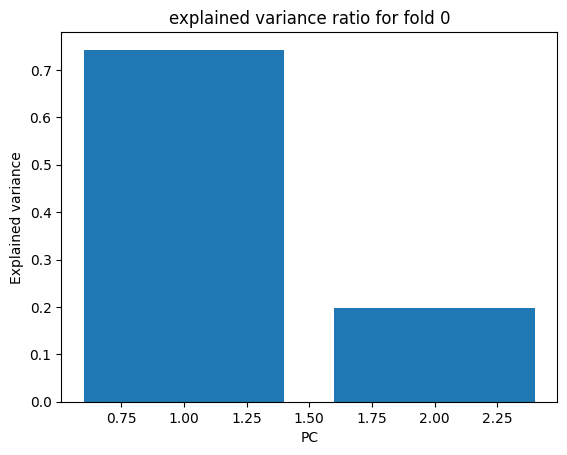

C:\Users\P095551\AppData\Local\Temp\ipykernel_9516\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


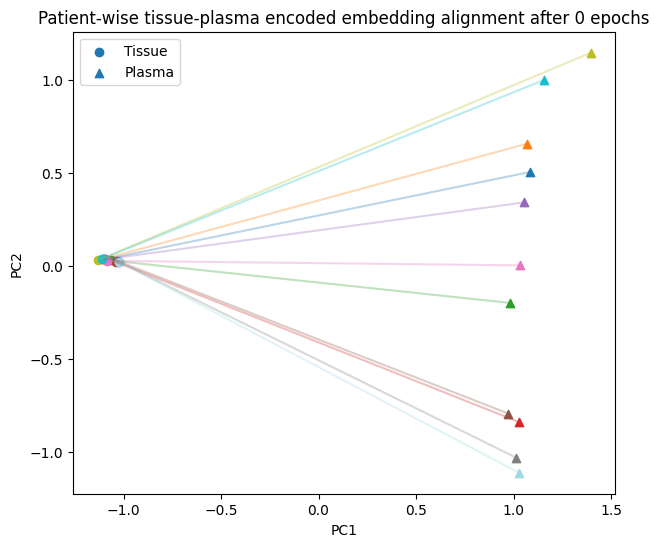

C:\Users\P095551\AppData\Local\Temp\ipykernel_9516\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


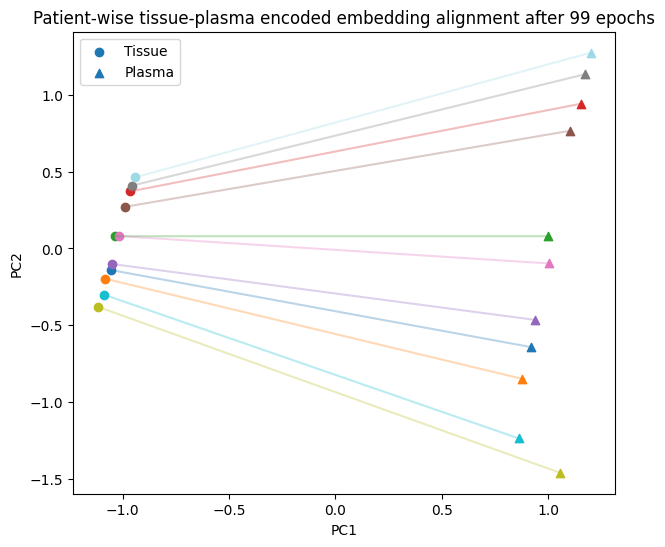

PC1 1.0
PC2 0.45454545454545453
Distances Fold 1
    PC  mean_distance  std_distance  fold
0  PC1       2.393253      0.262173     1
1  PC2       0.802671      0.408949     1
Fold 1 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             2.393252    -1.196626     1.196626     1
1  PC2             0.083898    -0.041949     0.041949     1


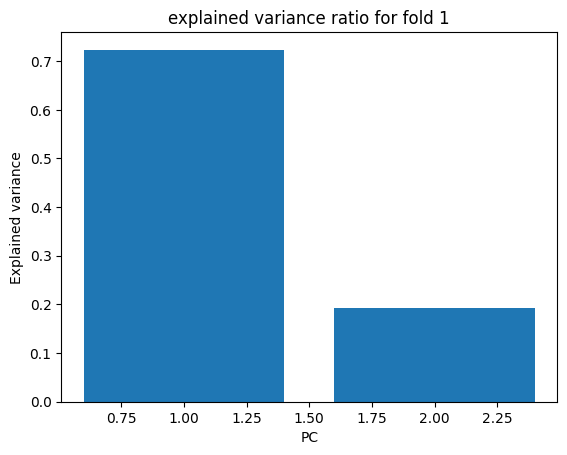

C:\Users\P095551\AppData\Local\Temp\ipykernel_9516\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


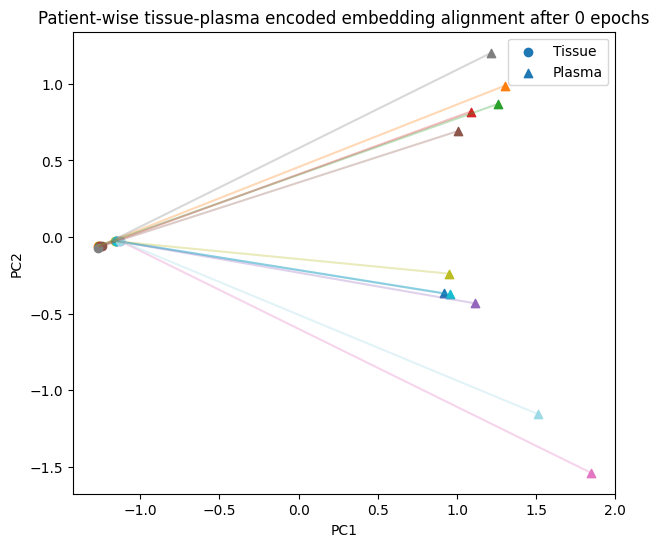

C:\Users\P095551\AppData\Local\Temp\ipykernel_9516\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


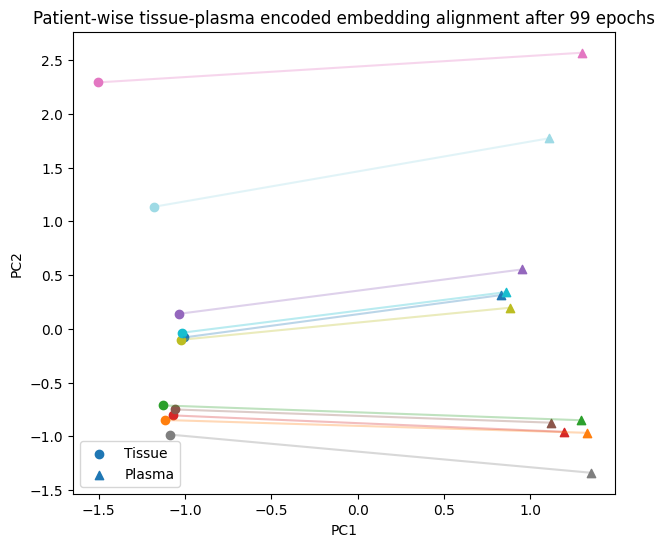

PC1 1.0
PC2 0.6
Distances Fold 2
    PC  mean_distance  std_distance  fold
0  PC1       2.633492      0.247208     2
1  PC2       0.599022      0.379836     2
Fold 2 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             2.633492    -1.316746     1.316746     2
1  PC2             0.119753    -0.059877     0.059877     2


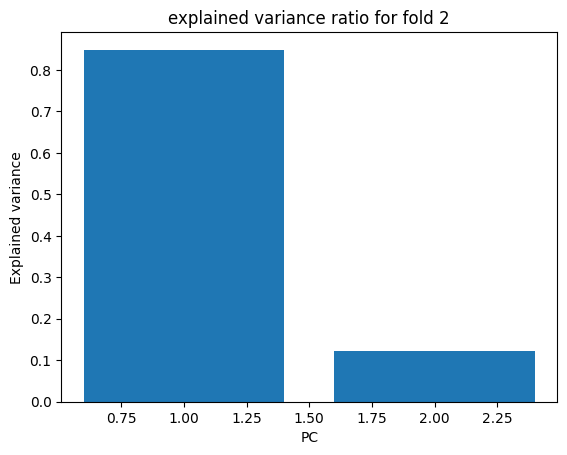

C:\Users\P095551\AppData\Local\Temp\ipykernel_9516\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


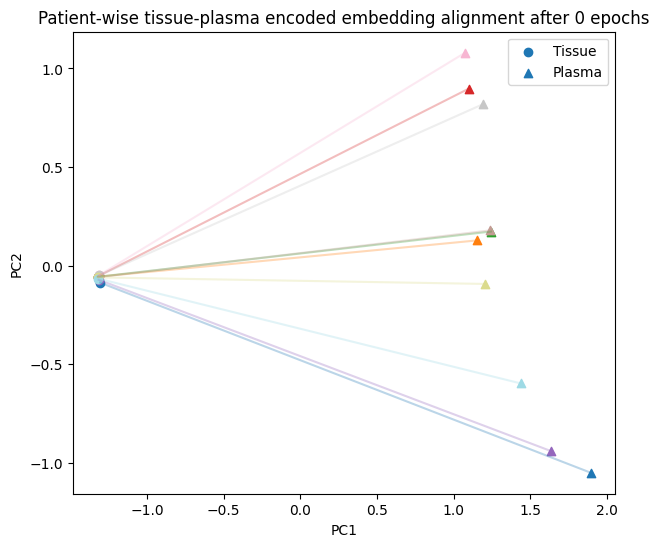

C:\Users\P095551\AppData\Local\Temp\ipykernel_9516\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


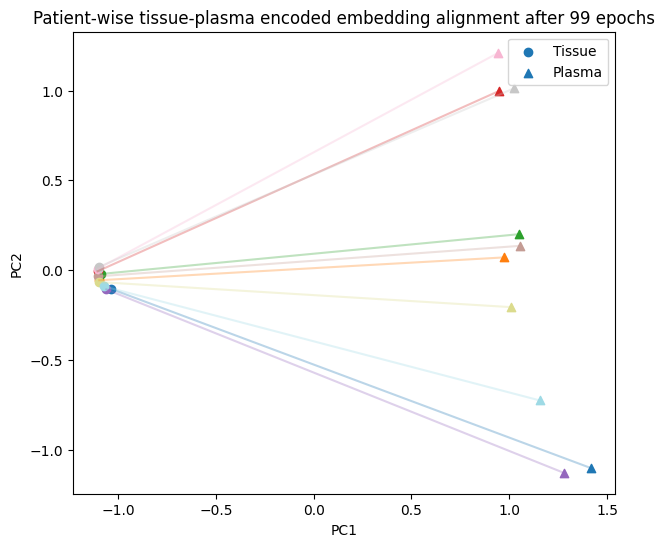

PC1 1.0
PC2 0.4
Distances Fold 3
    PC  mean_distance  std_distance  fold
0  PC1       2.237947      0.167603     3
1  PC2       0.622814      0.213748     3
Fold 3 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             2.237947    -1.118974     1.118974     3
1  PC2             0.108588     0.054294    -0.054294     3


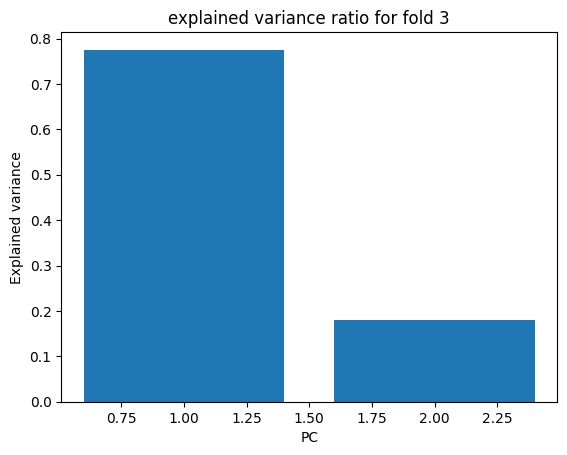

C:\Users\P095551\AppData\Local\Temp\ipykernel_9516\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


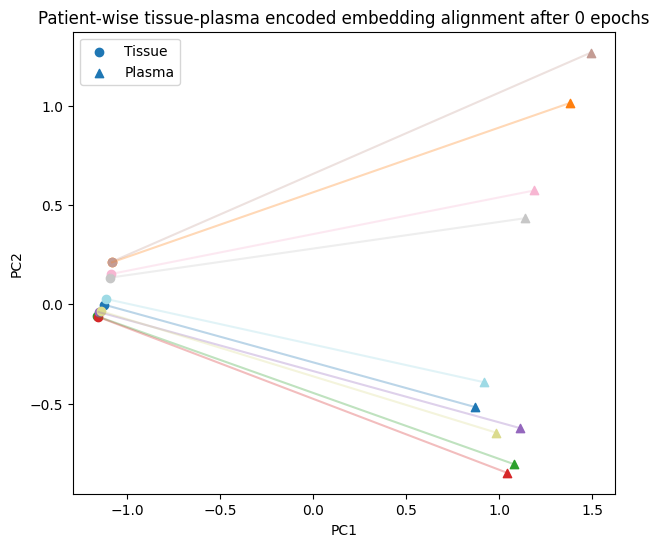

C:\Users\P095551\AppData\Local\Temp\ipykernel_9516\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


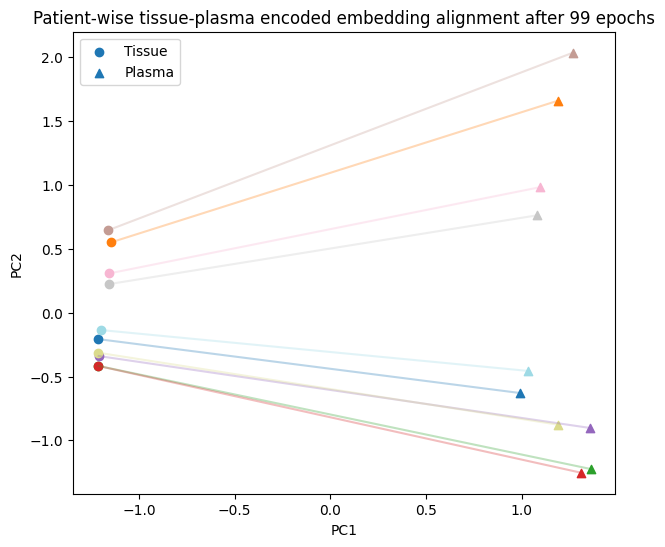

PC1 1.0
PC2 0.6
Distances Fold 4
    PC  mean_distance  std_distance  fold
0  PC1       2.527874      0.435900     4
1  PC2       0.912122      0.612007     4
Fold 4 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             2.527874    -1.263937     1.263937     4
1  PC2             0.252874     0.126437    -0.126437     4


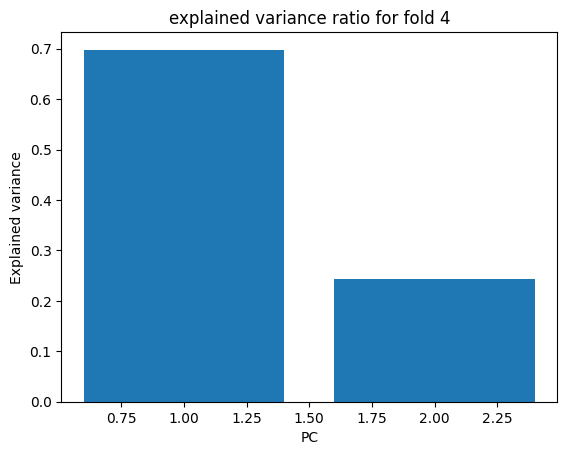

C:\Users\P095551\AppData\Local\Temp\ipykernel_9516\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


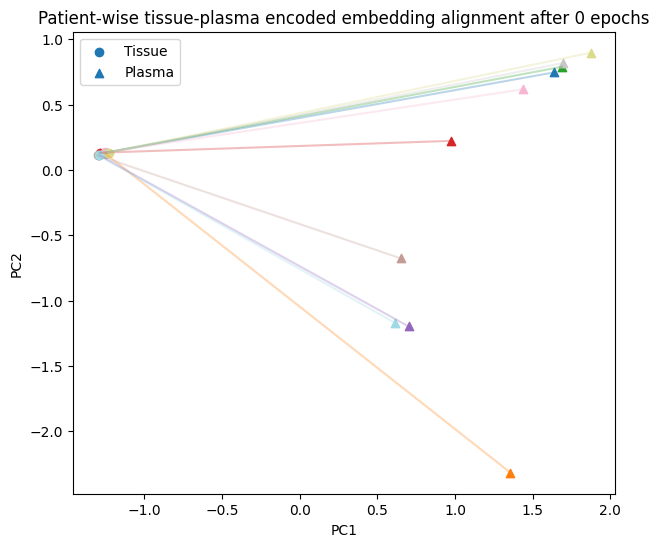

C:\Users\P095551\AppData\Local\Temp\ipykernel_9516\308324413.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


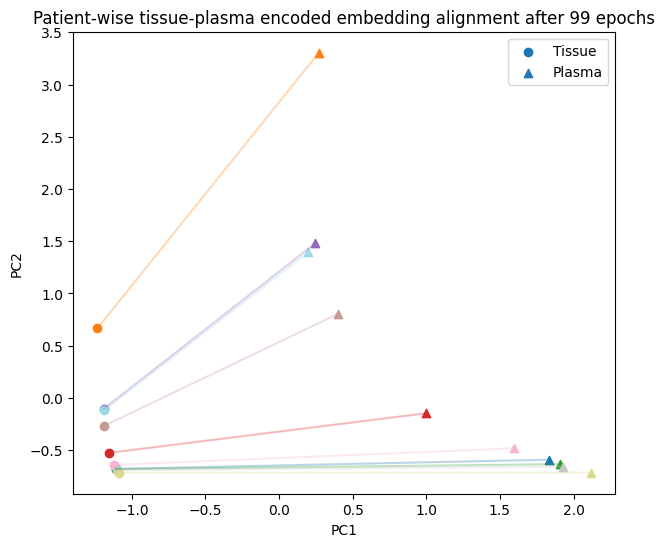

       patient modality       PC1       PC2  fold
0    Sample 15   Tissue -1.098758  0.034538     0
1    Sample 15   Plasma  1.084364  0.505196     0
2    Sample 17   Tissue -1.104474  0.036675     0
3    Sample 17   Plasma  1.068578  0.657237     0
4    Sample 28   Tissue -1.066732  0.029183     0
..         ...      ...       ...       ...   ...
99   Sample 72   Plasma  1.698411  0.818964     4
100  Sample 77   Tissue -1.229936  0.132386     4
101  Sample 77   Plasma  1.874153  0.897707     4
102  Sample 90   Tissue -1.294120  0.112355     4
103  Sample 90   Plasma  0.612725 -1.168941     4

[104 rows x 5 columns]


In [217]:
pc, all_distances, all_separations, all_variance = visualize_embeddings(proj=False)

In [101]:
print(pc.head())

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue -1.055641 -0.140609     0
1  Sample 15   Plasma  0.921344 -0.642128     0
2  Sample 17   Tissue -1.081169 -0.197666     0
3  Sample 17   Plasma  0.878996 -0.848706     0
4  Sample 28   Tissue -1.035897  0.079331     0


In [218]:
summary_df = (
    all_distances
    .groupby("PC")
    .agg(
        mean_distance_across_folds=("mean_distance", "mean"),
        std_distance_across_folds=("std_distance", "mean")

    )
    .reset_index()
)

print(summary_df)

    PC  mean_distance_across_folds  std_distance_across_folds
0  PC1                    2.388158                   0.250846
1  PC2                    0.725514                   0.396488


In [219]:
summary_df_2 = all_separations.groupby("PC").agg(
        mean_separation_across_folds=("modality_separation", "mean")).reset_index()


print(summary_df_2)

    PC  mean_separation_across_folds
0  PC1                      2.388157
1  PC2                      0.124805


In [220]:
print(all_distances)

    PC  mean_distance  std_distance  fold
0  PC1       2.148221      0.141344     0
1  PC2       0.690939      0.367902     0
2  PC1       2.393253      0.262173     1
3  PC2       0.802671      0.408949     1
4  PC1       2.633492      0.247208     2
5  PC2       0.599022      0.379836     2
6  PC1       2.237947      0.167603     3
7  PC2       0.622814      0.213748     3
8  PC1       2.527874      0.435900     4
9  PC2       0.912122      0.612007     4


In [221]:
variance_summary = (
    all_variance
    .groupby("PC")
    .agg(
        mean_variance=("explained_variance", "mean"),
        std_variance=("explained_variance", "std")
    )
    .reset_index()
)

print(variance_summary)

    PC  mean_variance  std_variance
0  PC1       0.757681      0.058215
1  PC2       0.187052      0.043297


In [102]:
tissue_scores = pd.read_csv('PR80_30/tissue_pathway_scores.csv')
plasma_scores = pd.read_csv('PR80_30/plasma_pathway_scores.csv')

In [83]:
tissue_scores.columns

Index(['Name', 'REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT',
       'REACTOME_ABC_TRANSPORTER_DISORDERS',
       'REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRIPT_IN_THE_ABSENCE_OF_TAT',
       'REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS',
       'REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_HINDBRAIN_DEVELOPMENT_DURING_EARLY_EMBRYOGENESIS',
       'REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS',
       'REACTOME_ACTIVATION_OF_BH3_ONLY_PROTEINS',
       'REACTOME_ACTIVATION_OF_GENE_EXPRESSION_BY_SREBF_SREBP',
       'REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS',
       ...
       'REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D',
       'REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A',
       'REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES', 'REACTOME_UCH_PROTEINASES',
       'REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR',
       'REACTOME_VASOPRESSIN_REGULATES_RENAL_WATER_HOMEOSTASIS_VIA_AQUAPORINS',
       'REACTOME_VEGFR

In [184]:
pathways_1 = set(tissue_scores.columns).intersection(plasma_scores.columns) 
pathways_1.remove('patient')
print(pathways_1)

{'REACTOME_DEVELOPMENTAL_CELL_LINEAGES_OF_THE_EXOCRINE_PANCREAS', 'REACTOME_FORMATION_OF_PARAXIAL_MESODERM', 'REACTOME_SARS_COV_INFECTIONS', 'REACTOME_INITIAL_TRIGGERING_OF_COMPLEMENT', 'REACTOME_TRANSCRIPTIONAL_REGULATION_BY_RUNX2', 'REACTOME_MITOCHONDRIAL_PROTEIN_DEGRADATION', 'REACTOME_RHO_GTPASE_EFFECTORS', 'REACTOME_TOLL_LIKE_RECEPTOR_CASCADES', 'REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSING_PRESENTATION', 'REACTOME_RAC2_GTPASE_CYCLE', 'REACTOME_DENGUE_VIRUS_ATTACHMENT_AND_ENTRY', 'REACTOME_CELL_CYCLE_CHECKPOINTS', 'REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT', 'REACTOME_TRANSLOCATION_OF_SLC2A4_GLUT4_TO_THE_PLASMA_MEMBRANE', 'REACTOME_CARGO_RECOGNITION_FOR_CLATHRIN_MEDIATED_ENDOCYTOSIS', 'REACTOME_RHOD_GTPASE_CYCLE', 'REACTOME_REGULATION_OF_MRNA_STABILITY_BY_PROTEINS_THAT_BIND_AU_RICH_ELEMENTS', 'REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION', 'REACTOME_DNA_REPAIR', 'REACTOME_SARS_COV_2_HOST_INTERACTIONS', 'REACTOME_EPH_EPHRIN_SIGNALING', 'REACTOME_AUTOPHAGY', 'REACTOME_CO

In [103]:
print(pc.head())

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue -1.055641 -0.140609     0
1  Sample 15   Plasma  0.921344 -0.642128     0
2  Sample 17   Tissue -1.081169 -0.197666     0
3  Sample 17   Plasma  0.878996 -0.848706     0
4  Sample 28   Tissue -1.035897  0.079331     0


In [185]:
merged = tissue_scores.merge(
    plasma_scores,
    on="patient",
    suffixes=("_tissue", "_plasma")
)

results = []

for pathway in pathways_1:

    tissue_col = f"{pathway}_tissue"
    plasma_col = f"{pathway}_plasma"

    # Only keep patients with both scores
    valid = merged[[tissue_col, plasma_col]].dropna()

    if len(valid) < 3:
        continue

    pearson_r, pearson_p = pearsonr(
        valid[tissue_col],
        valid[plasma_col]
    )

    spearman_r, spearman_p = spearmanr(
        valid[tissue_col],
        valid[plasma_col]
    )

    results.append({
        "pathway": pathway,
        "n": len(valid),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

pathway_correlations = pd.DataFrame(results)


In [186]:
print(pathway_correlations)

                                               pathway   n  pearson_r  \
0    REACTOME_DEVELOPMENTAL_CELL_LINEAGES_OF_THE_EX...  52  -0.107435   
1              REACTOME_FORMATION_OF_PARAXIAL_MESODERM  52  -0.040573   
2                         REACTOME_SARS_COV_INFECTIONS  52  -0.128560   
3            REACTOME_INITIAL_TRIGGERING_OF_COMPLEMENT  52   0.167309   
4         REACTOME_TRANSCRIPTIONAL_REGULATION_BY_RUNX2  52  -0.008501   
..                                                 ...  ..        ...   
304                    REACTOME_DENGUE_VIRUS_INFECTION  52   0.113386   
305                          REACTOME_DEUBIQUITINATION  52   0.027262   
306           REACTOME_ADHERENS_JUNCTIONS_INTERACTIONS  52  -0.061890   
307       REACTOME_TRANSCRIPTIONAL_REGULATION_BY_RUNX3  52  -0.124671   
308                       REACTOME_SELECTIVE_AUTOPHAGY  52   0.133750   

     pearson_p  spearman_r  spearman_p  
0     0.448398   -0.040724    0.774384  
1     0.775198   -0.108683    0.443113  


In [222]:
tissue_pc = pc[
    pc["modality"] == "Tissue"
]
print(tissue_pc.head())
plasma_pc = pc[pc['modality'] == 'Plasma']
print(plasma_pc.head())
tissue_scores = tissue_scores.rename(columns={"Name": "patient"})
plasma_scores = plasma_scores.rename(columns={"Name": "patient"})

merged_plasma = plasma_pc.merge(
    plasma_scores,
    on="patient",
    how="inner"
)
merged_tissue = tissue_pc.merge(
    tissue_scores,
    on="patient",
    how="inner"
)

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue -1.098758  0.034538     0
2  Sample 17   Tissue -1.104474  0.036675     0
4  Sample 28   Tissue -1.066732  0.029183     0
6  Sample 29   Tissue -1.036113  0.020302     0
8  Sample 34   Tissue -1.094063  0.035609     0
     patient modality       PC1       PC2  fold
1  Sample 15   Plasma  1.084364  0.505196     0
3  Sample 17   Plasma  1.068578  0.657237     0
5  Sample 28   Plasma  0.982611 -0.199356     0
7  Sample 29   Plasma  1.027748 -0.839945     0
9  Sample 34   Plasma  1.053523  0.341380     0


In [223]:
print(merged_tissue)

      patient modality       PC1       PC2  fold  \
0   Sample 15   Tissue -1.098758  0.034538     0   
1   Sample 17   Tissue -1.104474  0.036675     0   
2   Sample 28   Tissue -1.066732  0.029183     0   
3   Sample 29   Tissue -1.036113  0.020302     0   
4   Sample 34   Tissue -1.094063  0.035609     0   
5   Sample 38   Tissue -1.036026  0.028737     0   
6   Sample 61   Tissue -1.086299  0.027361     0   
7   Sample 76   Tissue -1.025754  0.022596     0   
8   Sample 78   Tissue -1.133131  0.030107     0   
9   Sample 85   Tissue -1.111661  0.037726     0   
10  Sample 88   Tissue -1.022204  0.021172     0   
11  Sample 16   Tissue -1.153396 -0.024845     1   
12  Sample 18   Tissue -1.266984 -0.059180     1   
13  Sample 22   Tissue -1.260562 -0.056674     1   
14  Sample 31   Tissue -1.252967 -0.061623     1   
15  Sample 49   Tissue -1.148351 -0.026128     1   
16  Sample 51   Tissue -1.243817 -0.059123     1   
17  Sample 64   Tissue -1.125764 -0.026529     1   
18  Sample 6

In [224]:
from scipy.stats import pearsonr, spearmanr


def correlate_pc_pathways(df, pc_cols=("PC1", "PC2")):
    results = []

    # pathway columns = everything except metadata + PCs
    metadata = {"patient", "modality", "fold", "Name"}
    pathway_cols = [
        col for col in df.columns
        if col not in metadata and col not in pc_cols
    ]

    for pc in pc_cols:
        for pathway in pathway_cols:

            # Remove missing values for this particular pair
            valid = df[[pc, pathway]].dropna()

            if len(valid) < 3:
                continue

            pearson_r, pearson_p = pearsonr(
                valid[pc],
                valid[pathway]
            )

            spearman_r, spearman_p = spearmanr(
                valid[pc],
                valid[pathway]
            )

            results.append({
                "PC": pc,
                "pathway": pathway,
                "n": len(valid),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p
            })

    return pd.DataFrame(results)

In [225]:
from statsmodels.stats.multitest import multipletests

def add_fdr(results):

    results = results.copy()

    results["pearson_fdr"] = multipletests(
        results["pearson_p"],
        method="fdr_bh"
    )[1]

    results["spearman_fdr"] = multipletests(
        results["spearman_p"],
        method="fdr_bh"
    )[1]

    return results

In [226]:
tissue_results = []

for fold in range(5):

    fold_df = merged_tissue[
        merged_tissue["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    tissue_results.append(result)

tissue_results = pd.concat(
    tissue_results,
    ignore_index=True
)

tissue_results.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
6192,PC2,REACTOME_SIGNALING_BY_TGF_BETA_RECEPTOR_COMPLEX,10,0.888713,0.000586,0.866667,0.001174,3
5121,PC1,REACTOME_MOLECULES_ASSOCIATED_WITH_ELASTIC_FIBRES,10,0.881635,0.000743,0.878788,0.000814,3
4915,PC1,REACTOME_ELASTIC_FIBRE_FORMATION,10,0.872091,0.001001,0.878788,0.000814,3
5908,PC2,REACTOME_MOLECULES_ASSOCIATED_WITH_ELASTIC_FIBRES,10,0.864311,0.001255,0.903030,0.000344,3
6884,PC1,REACTOME_RHO_GTPASES_ACTIVATE_ROCKS,10,0.862110,0.001335,0.806061,0.004862,4
5405,PC1,REACTOME_SIGNALING_BY_TGF_BETA_RECEPTOR_COMPLEX,10,0.860723,0.001387,0.878788,0.000814,3
6878,PC1,REACTOME_RHO_GTPASES_ACTIVATE_CIT,10,0.860581,0.001392,0.806061,0.004862,4
5702,PC2,REACTOME_ELASTIC_FIBRE_FORMATION,10,0.858251,0.001483,0.890909,0.000542,3
6191,PC2,REACTOME_SIGNALING_BY_TGFB_FAMILY_MEMBERS,10,0.856424,0.001558,0.672727,0.033041,3
6688,PC1,REACTOME_MITOPHAGY,10,0.851240,0.001783,0.890909,0.000542,4


In [227]:
plasma_results = []

for fold in range(5):

    fold_df = merged_plasma[
        merged_plasma["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    plasma_results.append(result)

plasma_results = pd.concat(
    plasma_results,
    ignore_index=True
)
plasma_results.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
965,PC2,REACTOME_ANTIMICROBIAL_MECHANISM_OF_IFN_STIMUL...,11,0.984128,4.574977e-08,0.936364,0.000022,1
1095,PC2,REACTOME_INTERFERON_SIGNALING,11,0.982384,7.294770e-08,0.909091,0.000106,1
998,PC2,REACTOME_CILIUM_ASSEMBLY,11,0.981141,9.896364e-08,0.863636,0.000612,1
1205,PC2,REACTOME_SARS_COV_1_INFECTION,11,0.980936,1.038738e-07,0.881818,0.000330,1
1038,PC2,REACTOME_DISEASES_OF_SIGNAL_TRANSDUCTION_BY_GR...,11,0.978957,1.615260e-07,0.945455,0.000011,1
3097,PC2,REACTOME_RHO_GTPASES_ACTIVATE_WASPS_AND_WAVES,10,0.977803,1.033992e-06,0.878788,0.000814,4
2892,PC2,REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS,10,0.976463,1.305057e-06,0.866667,0.001174,4
2902,PC2,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,10,0.976338,1.332914e-06,0.939394,0.000055,4
1086,PC2,REACTOME_HSP90_CHAPERONE_CYCLE_FOR_STEROID_HOR...,11,0.975877,2.973513e-07,0.900000,0.000160,1
960,PC2,REACTOME_ANCHORING_OF_THE_BASAL_BODY_TO_THE_PL...,11,0.974263,3.970509e-07,0.900000,0.000160,1


#### Cross modality pathway correlation

In [228]:
### Correlate tissue pc values with plasma pathway scores 
plasma_pathways = plasma_scores.copy()
tissue_pc_plasma_pathways = tissue_pc.merge(
    plasma_pathways,
    on="patient",
    how="inner"
)
cross_tissue_to_plasma = []

for fold in range(5):

    fold_df = tissue_pc_plasma_pathways[
        tissue_pc_plasma_pathways["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    cross_tissue_to_plasma.append(result)

cross_tissue_to_plasma = pd.concat(
    cross_tissue_to_plasma,
    ignore_index=True
)
cross_tissue_to_plasma.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
770,PC1,REACTOME_IMMUNOREGULATORY_INTERACTIONS_BETWEEN...,11,0.985177,3.368574e-08,0.909091,0.000106,1
892,PC1,REACTOME_SCAVENGING_OF_HEME_FROM_PLASMA,11,0.979822,1.338955e-07,0.881818,0.000330,1
668,PC1,REACTOME_CD22_MEDIATED_BCR_REGULATION,11,0.976995,2.405795e-07,0.863636,0.000612,1
714,PC1,REACTOME_DEVELOPMENTAL_CELL_LINEAGES_OF_THE_EX...,11,0.976467,2.662463e-07,0.918182,0.000067,1
884,PC1,REACTOME_ROLE_OF_LAT2_NTAL_LAB_ON_CALCIUM_MOBI...,11,0.976228,2.785302e-07,0.845455,0.001045,1
664,PC1,REACTOME_BINDING_AND_UPTAKE_OF_LIGANDS_BY_SCAV...,11,0.973147,4.798468e-07,0.827273,0.001677,1
1831,PC2,REACTOME_RHO_GTPASE_EFFECTORS,10,0.972872,2.293109e-06,0.927273,0.000112,2
644,PC1,REACTOME_ANTIGEN_ACTIVATES_B_CELL_RECEPTOR_BCR...,11,0.971309,6.446581e-07,0.872727,0.000455,1
696,PC1,REACTOME_CREATION_OF_C4_AND_C2_ACTIVATORS,11,0.970418,7.388618e-07,0.800000,0.003110,1
773,PC1,REACTOME_INITIAL_TRIGGERING_OF_COMPLEMENT,11,0.970330,7.487228e-07,0.800000,0.003110,1


In [229]:
### Correlate plasma embedding/PC scores with tissue pathway scores
#### this is the important one
tissue_pathways = tissue_scores.copy()
plasma_pc_tissue_pathways = plasma_pc.merge(
    tissue_scores,
    on="patient",
    how="inner"
)

cross_plasma_to_tissue = []

for fold in range(5):

    fold_df = plasma_pc_tissue_pathways[
        plasma_pc_tissue_pathways["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    cross_plasma_to_tissue.append(result)

cross_plasma_to_tissue = pd.concat(
    cross_plasma_to_tissue,
    ignore_index=True
)


In [230]:
tissue_results = add_fdr(tissue_results)
plasma_results = add_fdr(plasma_results)

cross_tissue_to_plasma = add_fdr(cross_tissue_to_plasma)
cross_plasma_to_tissue = add_fdr(cross_plasma_to_tissue)

In [231]:
cross_plasma_to_tissue[
    cross_plasma_to_tissue["PC"] == "PC2"
].sort_values(
    ["pearson_fdr",'spearman_fdr'],
    ascending=True
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
7687,PC2,REACTOME_RND2_GTPASE_CYCLE,10,0.944521,0.000039,0.939394,0.000055,4,0.293538,0.215797
917,PC2,REACTOME_DAP12_INTERACTIONS,11,0.896279,0.000188,0.809091,0.002559,0,0.476900,0.410939
918,PC2,REACTOME_DAP12_SIGNALING,11,0.878639,0.000370,0.809091,0.002559,0,0.476900,0.410939
6192,PC2,REACTOME_SIGNALING_BY_TGF_BETA_RECEPTOR_COMPLEX,10,0.897614,0.000424,0.806061,0.004862,3,0.476900,0.454205
1430,PC2,REACTOME_SIGNALING_BY_CSF1_M_CSF_IN_MYELOID_CELLS,11,0.829440,0.001590,0.881818,0.000330,0,0.604509,0.259843
5908,PC2,REACTOME_MOLECULES_ASSOCIATED_WITH_ELASTIC_FIBRES,10,0.855102,0.001613,0.866667,0.001174,3,0.604509,0.318474
7688,PC2,REACTOME_RND3_GTPASE_CYCLE,10,0.862142,0.001334,0.781818,0.007547,4,0.604509,0.486844
6191,PC2,REACTOME_SIGNALING_BY_TGFB_FAMILY_MEMBERS,10,0.858692,0.001466,0.636364,0.047912,3,0.604509,0.689333
1014,PC2,REACTOME_FLT3_SIGNALING,11,0.825045,0.001770,0.836364,0.001333,0,0.611892,0.338457
5702,PC2,REACTOME_ELASTIC_FIBRE_FORMATION,10,0.851131,0.001788,0.854545,0.001637,3,0.611892,0.356697


In [232]:
summary_plasma_to_tissue = (
    cross_plasma_to_tissue
    .groupby(["PC", "pathway"])
    .agg(
        # Pearson
        pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()),
        pearson_median_abs_r=("pearson_r", lambda x: x.abs().median()),
        pearson_min_abs_r=("pearson_r", lambda x: x.abs().min()),
        pearson_max_abs_r=("pearson_r", lambda x: x.abs().max()),

        # Spearman
        spearman_mean_abs_r=("spearman_r", lambda x: x.abs().mean()),
        spearman_median_abs_r=("spearman_r", lambda x: x.abs().median()),
        spearman_min_abs_r=("spearman_r", lambda x: x.abs().min()),
        spearman_max_abs_r=("spearman_r", lambda x: x.abs().max()),

        n_folds=("fold", "nunique"),
    )
    .reset_index()
)

print(summary_plasma_to_tissue)

       PC                                            pathway  \
0     PC1    REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT   
1     PC1                 REACTOME_ABC_TRANSPORTER_DISORDERS   
2     PC1  REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRI...   
3     PC1   REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS   
4     PC1  REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_H...   
...   ...                                                ...   
1569  PC2  REACTOME_VASOPRESSIN_REGULATES_RENAL_WATER_HOM...   
1570  PC2     REACTOME_VEGFR2_MEDIATED_VASCULAR_PERMEABILITY   
1571  PC2      REACTOME_VIF_MEDIATED_DEGRADATION_OF_APOBEC3G   
1572  PC2             REACTOME_VIRAL_MESSENGER_RNA_SYNTHESIS   
1573  PC2                  REACTOME_VISUAL_PHOTOTRANSDUCTION   

      pearson_mean_abs_r  pearson_median_abs_r  pearson_min_abs_r  \
0               0.171453              0.162826           0.026975   
1               0.208858              0.167663           0.000020   
2               0.384135

In [242]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["PC"] == "PC2") &
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['pearson_mean_abs_r'],
    ascending=False
).head(10)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
1468,PC2,REACTOME_SIGNALING_BY_TGFBR3,0.585530,0.516873,0.456791,0.787870,0.544848,0.515152,0.318182,0.818182,5
1055,PC2,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.530040,0.529324,0.172587,0.803308,0.426667,0.381818,0.072727,0.757576,5
855,PC2,REACTOME_CD209_DC_SIGN_SIGNALING,0.511098,0.505013,0.278159,0.752773,0.489091,0.500000,0.333333,0.636364,5
1169,PC2,REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.490682,0.436303,0.386626,0.749164,0.456970,0.463636,0.190909,0.793939,5
831,PC2,REACTOME_ATTENUATION_PHASE,0.489936,0.666588,0.017689,0.723305,0.463030,0.503030,0.115152,0.736364,5
1104,PC2,REACTOME_INTEGRIN_SIGNALING,0.477997,0.391133,0.148206,0.788099,0.439394,0.436364,0.127273,0.700000,5
1392,PC2,REACTOME_RND3_GTPASE_CYCLE,0.476626,0.412837,0.301594,0.862142,0.442424,0.445455,0.078788,0.781818,5
918,PC2,REACTOME_DAP12_SIGNALING,0.462826,0.251172,0.135931,0.878639,0.452727,0.454545,0.066667,0.830303,5
985,PC2,REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS,0.457986,0.495845,0.244220,0.662970,0.407879,0.454545,0.212121,0.563636,5
1269,PC2,REACTOME_PLATELET_ACTIVATION_SIGNALING_AND_AGG...,0.457151,0.500198,0.210632,0.675657,0.393333,0.478788,0.078788,0.581818,5


In [233]:
top_pearson = summary_plasma_to_tissue[
    (summary_plasma_to_tissue["PC"] == "PC2") &
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['pearson_mean_abs_r'],
    ascending=False
).head(5)['pathway'].tolist()

In [234]:
print(top_pearson)

['REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE', 'REACTOME_CD209_DC_SIGN_SIGNALING', 'REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION', 'REACTOME_ATTENUATION_PHASE']


In [235]:
tissue_pc_plasma_pathways.head()

     patient modality       PC1       PC2  fold  \
0  Sample 15   Tissue -1.098758  0.034538     0   
1  Sample 17   Tissue -1.104474  0.036675     0   
2  Sample 28   Tissue -1.066732  0.029183     0   
3  Sample 29   Tissue -1.036113  0.020302     0   
4  Sample 34   Tissue -1.094063  0.035609     0   

   REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT  \
0                                         0.204250   
1                                         0.026838   
2                                         0.159901   
3                                         0.268874   
4                                         0.197636   

   REACTOME_ABC_TRANSPORTER_DISORDERS  \
0                            0.214317   
1                            0.033465   
2                            0.154310   
3                            0.266008   
4                            0.194783   

   REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS  \
0                            

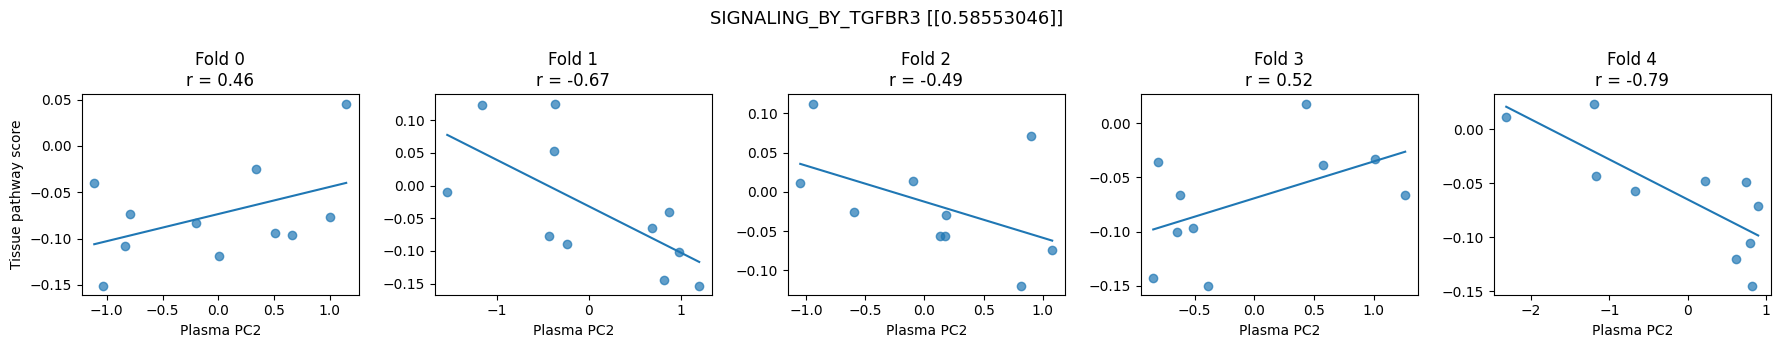

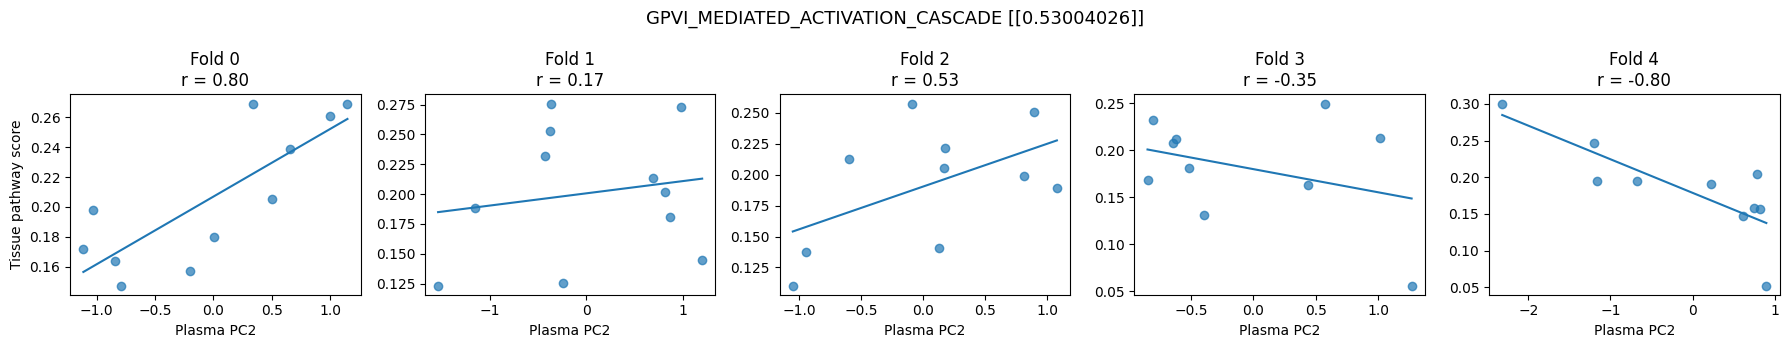

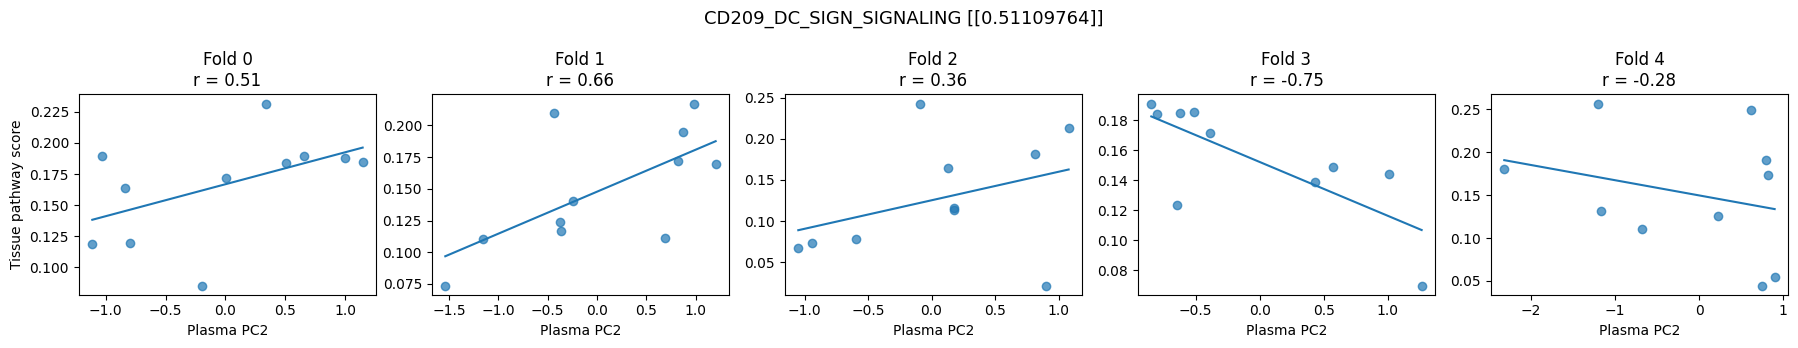

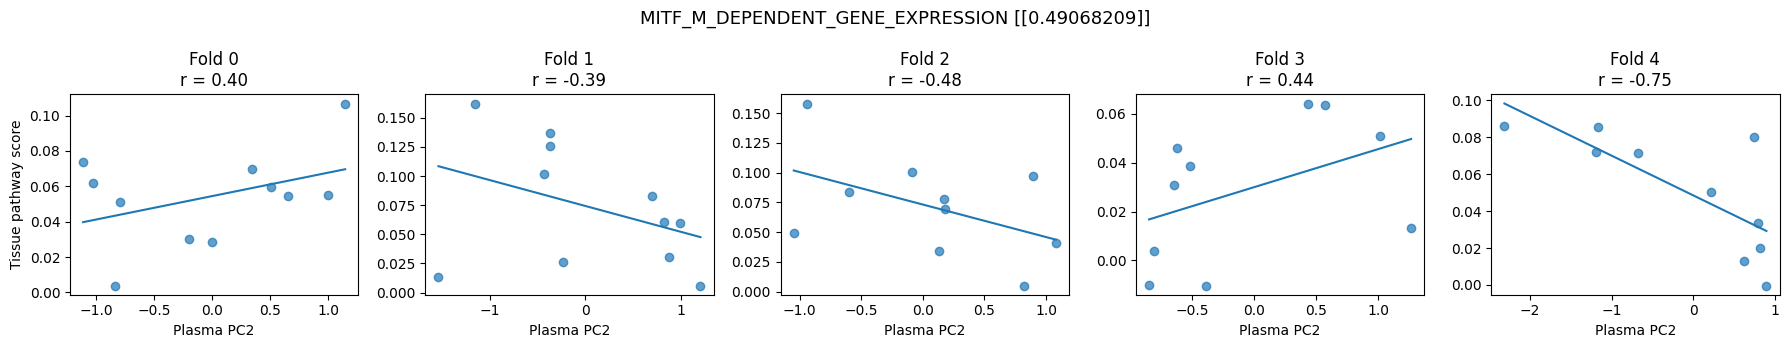

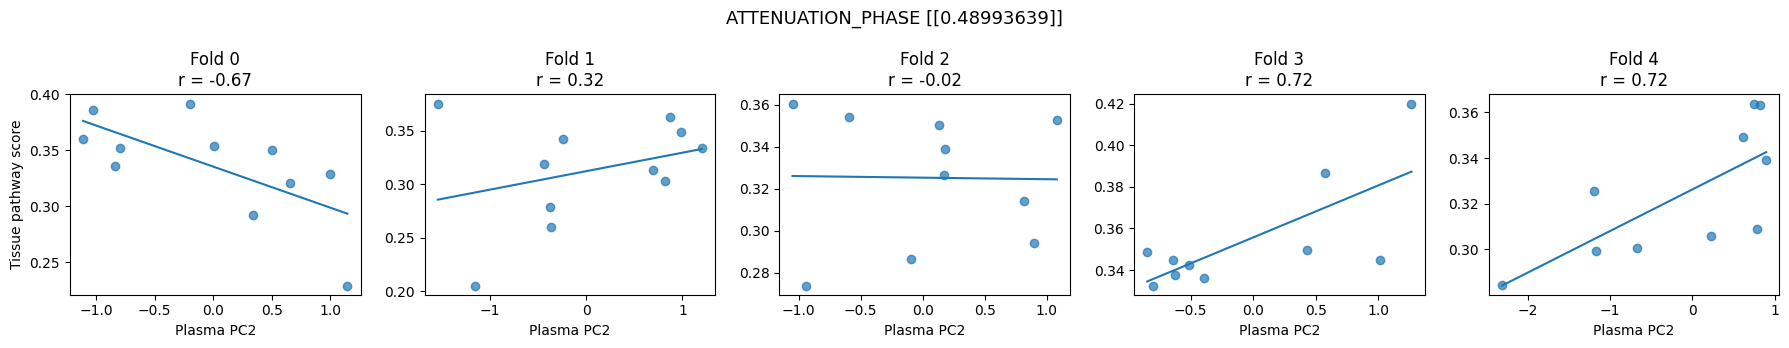

In [236]:
import matplotlib.pyplot as plt
import numpy as np

for pathway in top_pearson:

    pathway_df = cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC2") &
        (cross_plasma_to_tissue["pathway"] == pathway)
    ]

    fig, axes = plt.subplots(
        1, 5,
        figsize=(18, 3.5),
        sharex=False,
        sharey=False
    )

    for ax, (_, row) in zip(axes, pathway_df.iterrows()):

        fold = row["fold"]

        # Get the actual patient-level data for this fold
        fold_data = plasma_pc_tissue_pathways[
            plasma_pc_tissue_pathways["fold"] == fold
        ]

        x = fold_data["PC2"]
        y = fold_data[pathway]

        ax.scatter(x, y, alpha=0.7)

        # Regression line
        if len(x) >= 3:
            z = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = z[0] * x_line + z[1]
            ax.plot(x_line, y_line)

        ax.set_title(
            f"Fold {int(fold)}\n"
            f"r = {row['pearson_r']:.2f}"
        )

        ax.set_xlabel("Plasma PC2")

    axes[0].set_ylabel("Tissue pathway score")
    abs_r = pathway_df.agg(pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()))

    fig.suptitle(
        f'{pathway.replace("REACTOME_", "")} {(abs_r.values)}',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

In [237]:
top_pearson = (
    cross_plasma_to_tissue[
        cross_plasma_to_tissue["PC"] == "PC2"
    ]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
    .head(10)
    .index
)

plot_data = cross_plasma_to_tissue[
    (cross_plasma_to_tissue["PC"] == "PC2") &
    (cross_plasma_to_tissue["pathway"].isin(top_pearson))
].copy()

plot_data["abs_pearson_r"] = plot_data["pearson_r"].abs()

plot_df = plot_data.pivot(
    index="pathway",
    columns="fold",
    values="abs_pearson_r"
)
plot_df

fold,0,1,2,3,4
pathway,,,,,
REACTOME_ATTENUATION_PHASE,0.666588,0.321129,0.017689,0.720971,0.723305
REACTOME_CD209_DC_SIGN_SIGNALING,0.505013,0.655216,0.364327,0.752773,0.278159
REACTOME_DAP12_SIGNALING,0.878639,0.228635,0.251172,0.135931,0.819754
REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS,0.330648,0.556248,0.244220,0.662970,0.495845
REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.803308,0.172587,0.529324,0.348703,0.796279
REACTOME_INTEGRIN_SIGNALING,0.788099,0.391133,0.703236,0.359310,0.148206
REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.404800,0.386626,0.476517,0.436303,0.749164
REACTOME_PLATELET_ACTIVATION_SIGNALING_AND_AGGREGATION,0.646490,0.252777,0.500198,0.210632,0.675657
REACTOME_RND3_GTPASE_CYCLE,0.412837,0.301941,0.301594,0.504618,0.862142


In [238]:
print(top_pearson)

Index(['REACTOME_SIGNALING_BY_TGFBR3',
       'REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE',
       'REACTOME_CD209_DC_SIGN_SIGNALING',
       'REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION',
       'REACTOME_ATTENUATION_PHASE', 'REACTOME_INTEGRIN_SIGNALING',
       'REACTOME_RND3_GTPASE_CYCLE', 'REACTOME_DAP12_SIGNALING',
       'REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS',
       'REACTOME_PLATELET_ACTIVATION_SIGNALING_AND_AGGREGATION'],
      dtype='str', name='pathway')


In [209]:
print(type(top_pearson))
print(type(pathway_correlations))
print(pathway_correlations.head())

<class 'pandas.Index'>
<class 'pandas.DataFrame'>
                                             pathway   n  pearson_r  \
0  REACTOME_DEVELOPMENTAL_CELL_LINEAGES_OF_THE_EX...  52  -0.107435   
1            REACTOME_FORMATION_OF_PARAXIAL_MESODERM  52  -0.040573   
2                       REACTOME_SARS_COV_INFECTIONS  52  -0.128560   
3          REACTOME_INITIAL_TRIGGERING_OF_COMPLEMENT  52   0.167309   
4       REACTOME_TRANSCRIPTIONAL_REGULATION_BY_RUNX2  52  -0.008501   

   pearson_p  spearman_r  spearman_p  
0   0.448398   -0.040724    0.774384  
1   0.775198   -0.108683    0.443113  
2   0.363720   -0.172885    0.220335  
3   0.235806    0.201400    0.152221  
4   0.952303   -0.098267    0.488267  


In [202]:
print(len(plot_data['pathway']))

50


In [214]:
pathway_comp = (
    cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC2") &
        (cross_plasma_to_tissue["pathway"].isin(top_pearson))
    ]
    .groupby("pathway")
    .agg(
        pc_pathway_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .reset_index()
)

pathway_correlations_1 = pathway_correlations[
    pathway_correlations["pathway"].isin(top_pearson)
][["pathway", "pearson_r"]]

pathway_comp = pathway_comp.merge(
    pathway_correlations_1,
    on="pathway",
    how="left"
)

pathway_comp = pathway_comp.rename(columns={
    "pc_pathway_abs_r": "PC2 plasma → tissue pathway |r|",
    "pearson_r": "Plasma pathway ↔ tissue pathway r"
})

print(pathway_comp.head(10))

                                             pathway  \
0                         REACTOME_ATTENUATION_PHASE   
1                   REACTOME_CD209_DC_SIGN_SIGNALING   
2  REACTOME_CONSTITUTIVE_SIGNALING_BY_ABERRANT_PI...   
3    REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS   
4          REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE   
5                        REACTOME_INTEGRIN_SIGNALING   
6          REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION   
7                         REACTOME_RND3_GTPASE_CYCLE   
8                       REACTOME_SIGNALING_BY_TGFBR3   
9  REACTOME_SYNTHESIS_OF_PIPS_AT_THE_PLASMA_MEMBRANE   

   PC2 plasma → tissue pathway |r|  Plasma pathway ↔ tissue pathway r  
0                         0.464834                                NaN  
1                         0.499300                                NaN  
2                         0.457290                                NaN  
3                         0.460089                                NaN  
4                      

In [215]:
pathway_comp.head(10)

,pathway,PC2 plasma → tissue pathway |r|,Plasma pathway ↔ tissue pathway r
0,REACTOME_ATTENUATION_PHASE,0.464834,NaN
1,REACTOME_CD209_DC_SIGN_SIGNALING,0.499300,NaN
2,REACTOME_CONSTITUTIVE_SIGNALING_BY_ABERRANT_PI...,0.457290,NaN
3,REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS,0.460089,NaN
4,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.537829,NaN
5,REACTOME_INTEGRIN_SIGNALING,0.495519,-0.128994
6,REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.472715,-0.228976
7,REACTOME_RND3_GTPASE_CYCLE,0.462946,NaN
8,REACTOME_SIGNALING_BY_TGFBR3,0.574773,NaN
9,REACTOME_SYNTHESIS_OF_PIPS_AT_THE_PLASMA_MEMBRANE,0.457041,NaN


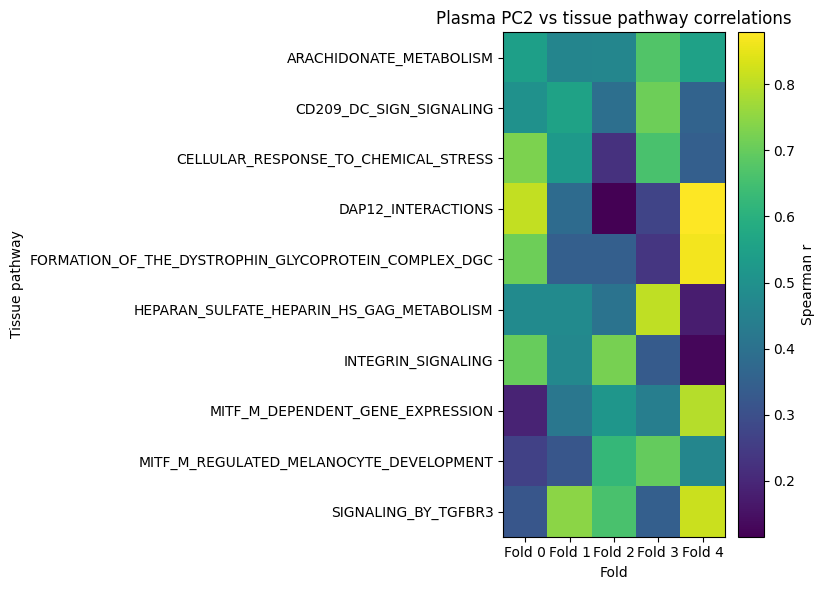

In [168]:
plt.figure(figsize=(8, 6))

plt.imshow(
    plot_df,
    aspect="auto"
)

plt.xticks(
    range(len(plot_df.columns)),
    [f"Fold {x}" for x in plot_df.columns]
)

plt.yticks(
    range(len(plot_df.index)),
    [
        x.replace("REACTOME_", "")
        for x in plot_df.index
    ]
)

plt.colorbar(label="Spearman r")

plt.xlabel("Fold")
plt.ylabel("Tissue pathway")
plt.title("Plasma PC2 vs tissue pathway correlations")

plt.tight_layout()
plt.show()

In [140]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["PC"] == "PC2") &
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['spearman_mean_abs_r'],
    ascending=False
).head(30)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
1468,PC2,REACTOME_SIGNALING_BY_TGFBR3,0.574773,0.516309,0.461192,0.774497,0.577576,0.660606,0.318182,0.818182,5
823,PC2,REACTOME_ARACHIDONATE_METABOLISM,0.434634,0.479960,0.153729,0.569800,0.540000,0.545455,0.463636,0.672727,5
855,PC2,REACTOME_CD209_DC_SIGN_SIGNALING,0.499300,0.481970,0.274181,0.753076,0.503030,0.500000,0.357576,0.709091,5
1024,PC2,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,0.415396,0.253318,0.123416,0.796729,0.500606,0.345455,0.236364,0.866667,5
861,PC2,REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS,0.367993,0.401709,0.074735,0.617684,0.496970,0.527273,0.224242,0.727273,5
917,PC2,REACTOME_DAP12_INTERACTIONS,0.400718,0.158422,0.028370,0.884269,0.491515,0.381818,0.115152,0.878788,5
1170,PC2,REACTOME_MITF_M_REGULATED_MELANOCYTE_DEVELOPMENT,0.418732,0.427511,0.127697,0.756171,0.473939,0.466667,0.263636,0.696970,5
1169,PC2,REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.472715,0.440410,0.290073,0.715812,0.472121,0.442424,0.190909,0.793939,5
1104,PC2,REACTOME_INTEGRIN_SIGNALING,0.495519,0.390553,0.224675,0.797647,0.470909,0.472727,0.127273,0.721212,5
1075,PC2,REACTOME_HEPARAN_SULFATE_HEPARIN_HS_GAG_METABO...,0.411043,0.489249,0.063085,0.578344,0.470303,0.481818,0.175758,0.806061,5


In [129]:
cross_tissue_to_plasma[
    cross_tissue_to_plasma["PC"] == "PC2"
].sort_values(
    ["pearson_fdr",'spearman_r'],
    ascending=True
).head(50)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
2502,PC2,REACTOME_SIGNALING_BY_VEGF,10,-0.976303,0.000001,-0.842424,0.002220,3,0.000974,0.012567
2902,PC2,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,10,-0.971598,0.000003,-0.939394,0.000055,4,0.001012,0.003219
3036,PC2,REACTOME_NERVOUS_SYSTEM_DEVELOPMENT,10,-0.967378,0.000005,-0.830303,0.002940,4,0.001052,0.014406
2940,PC2,REACTOME_DISEASES_OF_SIGNAL_TRANSDUCTION_BY_GR...,10,-0.967011,0.000005,-0.818182,0.003815,4,0.001052,0.016254
1095,PC2,REACTOME_INTERFERON_SIGNALING,11,-0.953240,0.000006,-0.881818,0.000330,1,0.001097,0.006260
2864,PC2,REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION,10,-0.964607,0.000007,-0.769697,0.009222,4,0.001097,0.026624
1703,PC2,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,10,-0.959713,0.000011,-0.963636,0.000007,2,0.001138,0.001289
412,PC2,REACTOME_ELASTIC_FIBRE_FORMATION,11,-0.946442,0.000010,-0.936364,0.000022,0,0.001138,0.001853
965,PC2,REACTOME_ANTIMICROBIAL_MECHANISM_OF_IFN_STIMUL...,11,-0.942812,0.000014,-0.927273,0.000040,1,0.001138,0.002930
1152,PC2,REACTOME_PLATELET_AGGREGATION_PLUG_FORMATION,11,-0.947603,0.000009,-0.881818,0.000330,1,0.001138,0.006260


In [121]:
cross_tissue_to_plasma.columns

Index(['PC', 'pathway', 'n', 'pearson_r', 'pearson_p', 'spearman_r',
       'spearman_p', 'fold', 'pearson_fdr', 'spearman_fdr'],
      dtype='str')

In [116]:
cross_plasma_to_tissue[
    cross_plasma_to_tissue["PC"] == "PC2"
].sort_values(
    "pearson_r",
    ascending=True
).head(20)

,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
7687,PC2,REACTOME_RND2_GTPASE_CYCLE,10,-0.908319,0.000276,-0.939394,0.000055,4,0.593317,0.262128
917,PC2,REACTOME_DAP12_INTERACTIONS,11,-0.884269,0.000302,-0.809091,0.002559,0,0.593317,0.510981
918,PC2,REACTOME_DAP12_SIGNALING,11,-0.867467,0.000541,-0.809091,0.002559,0,0.709869,0.510981
7688,PC2,REACTOME_RND3_GTPASE_CYCLE,10,-0.843226,0.002177,-0.781818,0.007547,4,0.777489,0.535090
2617,PC2,REACTOME_GLUCOSE_METABOLISM,11,-0.834927,0.001384,-0.709091,0.014552,1,0.777489,0.612431
1014,PC2,REACTOME_FLT3_SIGNALING,11,-0.824939,0.001775,-0.836364,0.001333,0,0.777489,0.476917
1430,PC2,REACTOME_SIGNALING_BY_CSF1_M_CSF_IN_MYELOID_CELLS,11,-0.823350,0.001844,-0.881818,0.000330,0,0.777489,0.338028
1335,PC2,REACTOME_REGULATION_OF_SIGNALING_BY_CBL,11,-0.797743,0.003260,-0.818182,0.002083,0,0.873036,0.510981
1104,PC2,REACTOME_INTEGRIN_SIGNALING,11,-0.797647,0.003267,-0.700000,0.016471,0,0.873036,0.641716
7320,PC2,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,10,-0.796729,0.005797,-0.866667,0.001174,4,0.931096,0.461787
